In [1]:
import numpy as np

X = np.load("X.npy")
y = np.load("y.npy")

print(X.shape)
print(y.shape)

(58912, 1250)
(58912,)


In [2]:
X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)

print(X.shape)

(58912, 1250, 1)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(47129, 1250, 1)
(11783, 1250, 1)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout
)

model = Sequential([
    
    Conv1D(
        32,
        kernel_size=5,
        activation='relu',
        input_shape=(1250,1)
    ),
    
    MaxPooling1D(pool_size=2),
    
    Conv1D(
        64,
        kernel_size=5,
        activation='relu'
    ),
    
    MaxPooling1D(pool_size=2),
    
    Flatten(),
    
    Dense(
        128,
        activation='relu'
    ),
    
    Dropout(0.5),
    
    Dense(
        1,
        activation='sigmoid'
    )
])

c:\Users\hrkap\OneDrive\Desktop\VitaTwin-AI project\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1246, 32)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 623, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 619, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 309, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 19776)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,531,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,542,081 (9.70 MB)

 Trainable params: 2,542,081 (9.70 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train[:5000],
    y_train[:5000],
    epochs=2,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.7793 - loss: 0.4840 - val_accuracy: 0.7950 - val_loss: 0.4154
Epoch 2/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.8112 - loss: 0.4151 - val_accuracy: 0.8090 - val_loss: 0.4221


In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 36s 62ms/step - accuracy: 0.8688 - loss: 0.3122 - val_accuracy: 0.9131 - val_loss: 0.2454
Epoch 2/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 36s 62ms/step - accuracy: 0.9119 - loss: 0.2271 - val_accuracy: 0.9253 - val_loss: 0.1977
Epoch 3/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 36s 62ms/step - accuracy: 0.9305 - loss: 0.1852 - val_accuracy: 0.9340 - val_loss: 0.1743
Epoch 4/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 37s 63ms/step - accuracy: 0.9430 - loss: 0.1506 - val_accuracy: 0.9402 - val_loss: 0.1553
Epoch 5/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 36s 62ms/step - accuracy: 0.9528 - loss: 0.1286 - val_accuracy: 0.9398 - val_loss: 0.1610
Epoch 6/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 37s 63ms/step - accuracy: 0.9592 - loss: 0.1076 - val_accuracy: 0.9454 - val_loss: 0.1497
Epoch 7/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 37s 62ms/step - accuracy: 0.9661 - loss: 0.0884 - val_accuracy: 0.9441 - val_loss: 0.1559
Epoch 8/10
590/590 ━━━━━━━━━━━━━━━━━━━━ 37s 63ms/step - accuracy: 0.9719 - loss: 0.0756 - 

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1246, 32)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 623, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 619, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 309, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 19776)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,531,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,626,245 (29.09 MB)

 Trainable params: 2,542,081 (9.70 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,084,164 (19.39 MB)

In [10]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

369/369 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9502 - loss: 0.1623
Test Accuracy: 0.9501824378967285
Test Loss: 0.1622547209262848


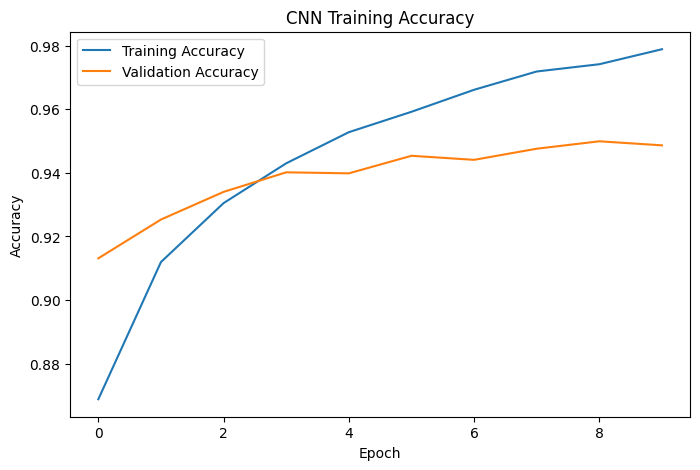

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("CNN Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()

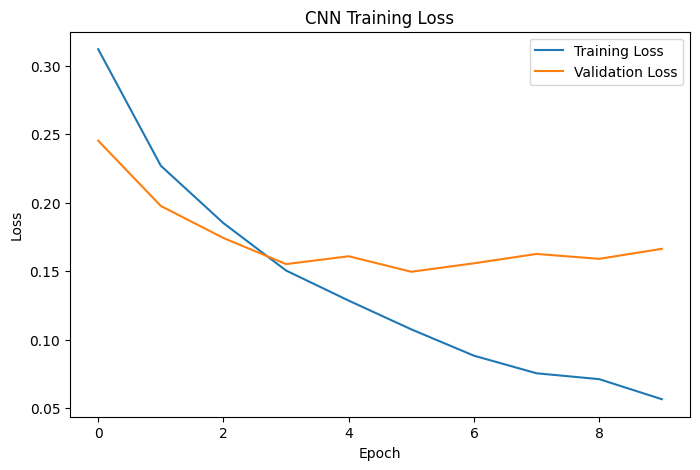

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("CNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()

369/369 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step


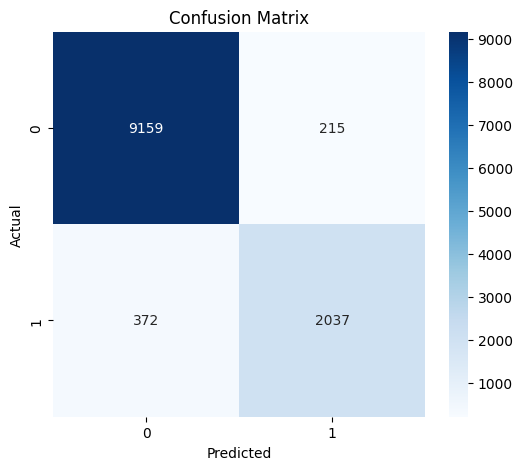

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [15]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      9374
           1       0.90      0.85      0.87      2409

    accuracy                           0.95     11783
   macro avg       0.93      0.91      0.92     11783
weighted avg       0.95      0.95      0.95     11783



In [16]:
model.save("../models/afib_cnn_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


In [17]:
import os

print(
    os.path.exists(
        "../models/afib_cnn_model.h5"
    )
)

True


In [19]:
model.save("afib_cnn_model.h5")

print("Model Saved")

Model Saved


In [18]:
import os

os.listdir()

['01_visualize_ecg.ipynb',
 '02_preprocessing.ipynb',
 '03_feature_extraction.ipynb',
 '04_afib_detection_model.ipynb',
 '05_dataset_builder.ipynb',
 '06_cnn_model_training.ipynb',
 '07_explainable_ai.ipynb',
 'X.npy',
 'y.npy']